# Phase 3.1 — The rotated surface code

The rotated surface code is the workhorse of today's experimental quantum error
correction: a distance-$d$ code on a $d \times d$ grid of data qubits with
$d^2 - 1$ measure (ancilla) qubits, encoding **one** logical qubit as
$[[d^2, 1, d]]$. Logical operators are homologically non-trivial strings spanning
the patch; stabilizers are weight-4 (bulk) and weight-2 (boundary) plaquette checks.

We build circuits **programmatically** with Stim (CLAUDE.md rule) via the
promoted helper :class:`qec_project.codes.surface.RotatedSurfaceCode`, which wraps
``stim.Circuit.generated``. The decomposed *detector error model* (DEM) it returns
is the object every decoder in Phase 3.3 consumes.

References (`docs/reading-list.md`): Fowler et al. 2012 (arXiv:1208.0928);
Gidney, *Stim* (doi:10.22331/q-2021-07-06-497).

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from qec_project.codes.surface import RotatedSurfaceCode
from qec_project.noise.circuit import depolarizing

noise = depolarizing(0.005)  # uniform circuit-level depolarizing, p = 0.5%
print(f"{'d':>3} {'data':>5} {'detectors':>10} {'observables':>12} {'dem_errors':>11}")
for d in (3, 5, 7):
    code = RotatedSurfaceCode.memory(d)
    circ = code.circuit(noise)
    dem = code.detector_error_model(noise)
    print(f"{d:>3} {code.num_data_qubits:>5} {circ.num_detectors:>10} "
          f"{circ.num_observables:>12} {dem.num_errors:>11}")

  d  data  detectors  observables  dem_errors
  3     9         24            1         286
  5    25        120            1        1953
  7    49        336            1        6602


## The memory circuit

A *memory* experiment initialises the logical qubit, runs $d$ rounds of
stabilizer measurement under noise, then reads out. Detectors compare a
stabilizer measurement to the previous round (so a noiseless run fires **no**
detectors). Here is the first slice of the $d=3$ circuit.

In [2]:
d3 = RotatedSurfaceCode.memory(3)
print(repr(d3))
print(str(d3.circuit(noise))[:700], "...")

RotatedSurfaceCode(distance=3, rounds=3, basis='Z')
QUBIT_COORDS(1, 1) 1
QUBIT_COORDS(2, 0) 2
QUBIT_COORDS(3, 1) 3
QUBIT_COORDS(5, 1) 5
QUBIT_COORDS(1, 3) 8
QUBIT_COORDS(2, 2) 9
QUBIT_COORDS(3, 3) 10
QUBIT_COORDS(4, 2) 11
QUBIT_COORDS(5, 3) 12
QUBIT_COORDS(6, 2) 13
QUBIT_COORDS(0, 4) 14
QUBIT_COORDS(1, 5) 15
QUBIT_COORDS(2, 4) 16
QUBIT_COORDS(3, 5) 17
QUBIT_COORDS(4, 4) 18
QUBIT_COORDS(5, 5) 19
QUBIT_COORDS(4, 6) 25
R 1 3 5 8 10 12 15 17 19
X_ERROR(0.005) 1 3 5 8 10 12 15 17 19
R 2 9 11 13 14 16 18 25
X_ERROR(0.005) 2 9 11 13 14 16 18 25
TICK
DEPOLARIZE1(0.005) 1 3 5 8 10 12 15 17 19
H 2 11 16 25
DEPOLARIZE1(0.005) 2 11 16 25
TICK
CX 2 3 16 17 11 12 15 14 10 9 19 18
DEPOLARIZE2(0.005) 2 3 16 17 11 12 15 14 10 9 19 18
TICK
CX 2 1 16 15 11 10 8 ...


## The code lattice

Stim annotates each detector with `(x, y, t)` coordinates. Projecting the first
round onto the plane shows the rotated-surface-code check layout — the
checkerboard of $X$- and $Z$-type plaquettes.

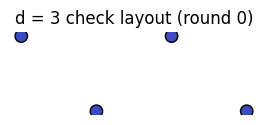

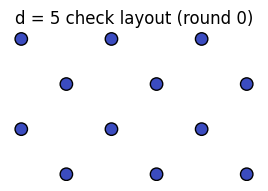

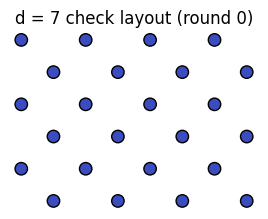

In [3]:
for d in (3, 5, 7):
    circ = RotatedSurfaceCode.memory(d).circuit(noise)
    coords = circ.get_detector_coordinates()
    pts = np.array([coords[i][:2] for i in coords if coords[i][2] == 0.0])
    plt.figure(figsize=(3.2, 3.2))
    plt.scatter(pts[:, 0], pts[:, 1], c=(pts[:, 0] + pts[:, 1]) % 2, cmap="coolwarm", s=80, edgecolors="k")
    plt.title(f"d = {d} check layout (round 0)")
    plt.gca().set_aspect("equal")
    plt.axis("off")
    plt.show()

## Detector error model

`decompose_errors=True` rewrites every circuit-level error mechanism as a set of
*graphlike* edges between detectors (plus boundary edges), which is exactly what a
minimum-weight matching decoder needs (Phase 3.3). The error count grows with both
distance and the number of rounds.

In [4]:
dem = RotatedSurfaceCode.memory(5).detector_error_model(noise)
print(f"d=5 DEM: {dem.num_detectors} detectors, {dem.num_observables} observable, "
      f"{dem.num_errors} error mechanisms")
# DEM construction is deterministic for fixed parameters:
again = RotatedSurfaceCode.memory(5).detector_error_model(noise)
print("DEM reproducible:", str(dem) == str(again))

d=5 DEM: 120 detectors, 1 observable, 1953 error mechanisms
DEM reproducible: True


## Recap

* `RotatedSurfaceCode.memory(d)` builds a $[[d^2,1,d]]$ memory experiment
  programmatically; $d=3,5,7$ give $24/120/336$ detectors here.
* A noiseless circuit fires no detectors; `decompose_errors=True` yields a
  graphlike DEM for matching.
* **Next (3.2):** read the syndrome stream; **(3.3):** decode it with PyMatching;
  **(3.4):** sweep $p$ and $d$ to find the threshold.